In [16]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
from torch.nn.init import kaiming_uniform_
from torch.distributions import Normal
from scipy.ndimage.filters import uniform_filter1d
from matplotlib import pyplot as plt
from collections import namedtuple
from IPython.display import clear_output
from env.drone_env import DroneEnv
env = DroneEnv(render_mode=None, target_pos=[0.0, 0.0, 1.0])
import mlflow
import mlflow.pytorch
print(mlflow.get_tracking_uri())

sqlite:////home/kikumu/Documents/Drone/mlflow.db


/tmp/ipykernel_111528/1059488642.py:10: DeprecationWarning: Please import `uniform_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import uniform_filter1d


In [17]:
import numpy as np
# import gym
from tqdm import tqdm
import random as rand
from itertools import count
import time
# import gym

In [18]:
class ReplayMemory():
    def __init__(self,capacity):   
        self.capacity = capacity
        self.memory = {}
        self.push_count = 0
        
    def push(self, timestep, experience):
        if len(self.memory) < self.capacity:
            self.memory[timestep] = experience
        else:
            del_key = None
            for k in self.memory.keys():
                del_key = k
                break
            self.memory.pop(del_key, None)
            self.memory[timestep] = experience
        self.push_count+=1
    
    def sample(self, batch_size):
        batch_tuple = random.sample(list(self.memory.items()), batch_size)#key(timestep), experiences
        experience_array = []
        for timestep, experiences in batch_tuple:
            experience_array.append(experiences)
        return experience_array
    
    def can_provide_sample(self, batch_size):
        return len(self.memory)>=batch_size
    
    def update_td_error(self, sampled_experiences, timesteps):
        for i in range(len(timesteps)):
            self.memory[timesteps[i]] = sampled_experiences[i]
        
    def get_memory_values(self):
        return self.memory 

In [19]:
class Agent():
    def __init__(self, env, ReplayMemory, online_policy, online_q_a, online_q_b,\
                online_policy_optimizer,online_q_network_optimizer_a, online_q_network_optimizer_b, target_q_a,\
                target_q_b, gamma=0.99, alpha_pr=0.4, beta_pr=0.3,\
                tau=0.01, n_ep=120, max_steps=100000, memory_size=1000000, batch_size=20,\
                policy_update_step=2, target_update=50, min_sample_size=500, warm_up=2,\
                rank_based_prioritization=True, utd_ratio=4):
        
        
        self.env = env
        self.tau = tau
        self.gamma = gamma
        self.alpha_pr = alpha_pr
        self.beta_pr = beta_pr
        self.agent_max_memory=memory_size
        self.batch_size = batch_size
        self.n_ep = n_ep
        self.max_steps = max_steps
        self.min_sample_size=min_sample_size
        self.target_update=target_update
        self.policy_update_step=policy_update_step
        self.online_policy_network = online_policy
        self.online_policy_optimizer = online_policy_optimizer
        self.online_q_network_a = online_q_a
        self.online_q_network_optimizer_a = online_q_network_optimizer_a
        self.online_q_network_b = online_q_b
        self.online_q_network_optimizer_b = online_q_network_optimizer_b
        self.target_q_network_a = target_q_a
        self.target_q_network_b = target_q_b
        self.current_timestep = 0
        self.warm_up = warm_up
        self.agent_memory = ReplayMemory(self.agent_max_memory)
        self.device = torch.device("cuda" if torch.cuda.is_available()\
                        else "cpu")
        self.Xp = namedtuple('Experience',
                        ('state', 'action', 'next_state', 'reward', 'done', 'abs_td_error','timestep'))
        self.rank_based = rank_based_prioritization
        self.max_norm = 0.5
        self.utd_ratio = utd_ratio
        
    def extract_tensors(self, experiences):
        batch = self.Xp(*zip(*experiences))
        state = np.stack(batch.state) #stack
        action = np.stack(batch.action)
        next_state = np.stack(batch.next_state)
        reward = np.stack(batch.reward)
        done = np.stack(batch.done)
        abs_td_error = np.stack(batch.abs_td_error)
        timestep = np.stack(batch.timestep)
        return state,action,next_state,reward,done,abs_td_error,timestep
    
    def rebuild_experiences(self, state, action, next_state, reward, done, abs_error, timestep):
        exp_list = []
        for idx_ in range(len(state)):
            exp_list.append(\
                        self.Xp(state[idx_], action[idx_], next_state[idx_], reward[idx_],\
                           done[idx_], abs_error[idx_], timestep[idx_]))
        return exp_list 
    
    def prioritize_samples(self, experience_samples, alpha, beta,\
                           epsilon = 1e-6):
        state,action,next_state,reward,done,abs_td_error,timesteps \
                            = self.extract_tensors(experience_samples)
        
        if self.rank_based == True:
            abs_td_error, indices_ = (list(t) for t in zip(*sorted(\
                            zip(abs_td_error.tolist(), timesteps))))
            abs_td_error.reverse()
            indices_.reverse()#reverse to march sort func
            abs_td_error = np.array(abs_td_error)
            abs_td_error  = torch.tensor(abs_td_error)
            ranks = np.arange(1, len(abs_td_error)+1)
            priorities = 1.0/ranks
        else:
            priorities = abs_td_error + epsilon
            indices_ = None
        
        priorities = priorities**alpha
        priorities = np.expand_dims(priorities, axis=1)
        probabilities = priorities/np.sum(priorities, axis=0)
        assert np.isclose(probabilities.sum(), 1.0)
        number_of_samples  = len(probabilities)
        weight_importance_ = number_of_samples*probabilities
        weight_importance_ = weight_importance_**-beta
        weight_importance_max = np.max(weight_importance_)
        weight_importance_scaled = weight_importance_/weight_importance_max
        return weight_importance_scaled, indices_ 
    
    def update_model(self, experience_samples,\
                weighted_importance, timestep_indices):
        
        states, actions, next_states, rewards, done, _ , timesteps =\
                    self.extract_tensors(experience_samples)
        
        if self.rank_based == True:
            arrange_weighted_values = [timestep_indices.index(i) for i in timesteps]
        
        states = torch.tensor(np.squeeze(states)).float().to(self.device)
        next_states = torch.tensor(np.squeeze(next_states)).float().to(self.device)
        actions = torch.tensor(actions).float().to(self.device)
        rewards = torch.tensor(rewards).unsqueeze(1).float().to(self.device)
        done = torch.tensor(done).unsqueeze(1).float().to(self.device)
        weighted_importance = torch.tensor(weighted_importance).float().to(self.device)
    
        #optimize alpha
        current_actions,_, log_pi_s = self.online_policy_network.full_pass(states)
        target_alpha = (self.online_policy_network.target_entropy +\
                   log_pi_s).detach()
        alpha_loss = -(self.online_policy_network.log_alpha*\
                 target_alpha).mean()
        self.online_policy_network.target_entropy_optimizer.zero_grad()
        alpha_loss.backward()
        self.online_policy_network.target_entropy_optimizer.step()
    
        #set alpha
        alpha = self.online_policy_network.log_alpha.exp()
    
        #optimize online using target nets
        predicted_action_policy,_, log_pi_ns =\
                        self.online_policy_network.full_pass(next_states)

        qsa_target_a = self.target_q_network_a(next_states,\
                                        predicted_action_policy)
        qsa_target_b = self.target_q_network_b(next_states,\
                                        predicted_action_policy)
        target_qsa = torch.min(qsa_target_a, qsa_target_b)
        target_qsa = target_qsa - alpha*log_pi_ns
        target_qsa = rewards + self.gamma*target_qsa*(1 - done)
        #target_qsa = target_qsa*weighted_importance
        #print(weighted_importance)
        target_qsa = target_qsa.detach()
        qsa_online_a = self.online_q_network_a(states, actions)
        qsa_online_b = self.online_q_network_b(states, actions)
        
        #qsa_online_a = qsa_online_a*weighted_importance.detach()
        #qsa_online_b = qsa_online_b*weighted_importance.detach()
    
        #update online networks
        loss_func = torch.nn.SmoothL1Loss(reduction='none')
        qa_loss = (weighted_importance.detach() * loss_func(qsa_online_a,\
                            target_qsa.detach())).mean()
        qb_loss = (weighted_importance.detach() * loss_func(qsa_online_b,\
                            target_qsa.detach())).mean()
        if self.current_timestep%500 == 0:
            print(f"(Q_a loss:  {qa_loss.item():.4f}")
            print(f"(Q_b loss:  {qb_loss.item():.4f}")
            print(f"(Q_a values:  min={qsa_online_a.min().item():.4f} max={qsa_online_a.max().item():.4f}")
            print(f"(Targets Q:  min={target_qsa.min().item():.4f} max={target_qsa.max().item():.4f}")
            print(f"(alpha:  {self.online_policy_network.log_alpha.exp().item():.4f}")
            print(f"log_pi: {log_pi_s.mean().item():.4f}")
            print(f"target_entropy: {self.online_policy_network.target_entropy:.4f}")
            
            
        self.online_q_network_optimizer_a.zero_grad()
        qa_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_q_network_a.parameters(), max_norm=self.max_norm)  # gradient clip
        self.online_q_network_optimizer_a.step()
    
        self.online_q_network_optimizer_b.zero_grad()
        qb_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_q_network_b.parameters(), max_norm=self.max_norm)  # ← here
        self.online_q_network_optimizer_b.step()
    
        abs_a = (target_qsa.squeeze() - qsa_online_a.squeeze())
        abs_b = (target_qsa.squeeze() - qsa_online_b.squeeze())
        ovr_update = (abs_a + abs_b)/2
        ovr_update = abs(ovr_update.detach().cpu().numpy())
        if self.current_timestep % self.policy_update_step == 0:
            current_actions,_ , log_pi = self.online_policy_network.full_pass(states)

            #print(f"sum: {(self.online_policy_network.target_entropy + log_pi).mean().item():.4f}")
            #print(f"mean actions: {_.mean().item():.4f}")
            
            qsa_online_a = self.online_q_network_a(states, current_actions)
            qsa_online_b = self.online_q_network_b(states, current_actions)
            qsa_min = torch.min(qsa_online_a, qsa_online_b)
            policy_loss = (alpha*log_pi\
                      -qsa_min).mean()
            if self.current_timestep % 500 == 0:
                print(f"policy loss: {policy_loss.item():.4f}")
                print(f"sum: {(self.online_policy_network.target_entropy + log_pi).mean().item():.4f}")
                print(f"mean actions: {_.mean().item():.4f}")
                
            self.online_policy_optimizer.zero_grad()
            policy_loss.backward()
            if self.current_timestep % 500 == 0:
                print("before gradnorm")
                mean_layer_grad = self.online_policy_network.mean_layer.weight.grad
                dist_layer_grad = self.online_policy_network.distribution_layer.weight.grad
                input_layer_grad = self.online_policy_network.input_layer.weight.grad
    
                print(f"mean_layer grad norm:  {mean_layer_grad.norm().item():.6f}")
                print(f"dist_layer grad norm:  {dist_layer_grad.norm().item():.6f}")
                print(f"input_layer grad norm: {input_layer_grad.norm().item():.6f}")
                
            torch.nn.utils.clip_grad_norm_(self.online_policy_network.parameters(), max_norm=self.max_norm)  # ← here
            
            if self.current_timestep % 500 == 0:
                print("after gradnorm")
                mean_layer_grad = self.online_policy_network.mean_layer.weight.grad
                dist_layer_grad = self.online_policy_network.distribution_layer.weight.grad
                input_layer_grad = self.online_policy_network.input_layer.weight.grad
    
                print(f"mean_layer grad norm:  {mean_layer_grad.norm().item():.6f}")
                print(f"dist_layer grad norm:  {dist_layer_grad.norm().item():.6f}")
                print(f"input_layer grad norm: {input_layer_grad.norm().item():.6f}")

                with torch.no_grad():
                    test_state = torch.tensor([
                    0.0, 0.0, 0.5,    # pos — drone 0.5m up, target is 1m
                    0.0, 0.0, 0.0,    # vel
                    0.0, 0.0, 0.0,    # rpy
                    0.0, 0.0, 0.0,    # ang_vel
                    0.0, 0.0, 0.5,    # error — 0.5m below target
                    0.5,               # dist
                    0.5, 0.5, 0.5, 0.5
                    ], dtype=torch.float32).unsqueeze(0).to("cpu")
                    self.online_policy_network.eval()
                    test_mean, _ = self.online_policy_network.forward(test_state)
                    self.online_policy_network.train()
                    print(f"test_mean: {test_mean.detach().cpu().numpy()}")
                    
            #if self.current_timestep%100 == 0:
            mean_layer_grad = self.online_policy_network.mean_layer.weight.grad
            dist_layer_grad = self.online_policy_network.distribution_layer.weight.grad
            input_layer_grad = self.online_policy_network.input_layer.weight.grad
            
            metrics = {
            "q_a_loss":    qa_loss.item(),
            "q_b_loss":    qb_loss.item(),
            "alpha":       self.online_policy_network.log_alpha.exp().item(),
            "log_pi":      log_pi_s.mean().item(),
            "q_a_min":     qsa_online_a.min().item(),
            "q_a_max":     qsa_online_a.max().item(),
            "sum":         (self.online_policy_network.target_entropy + log_pi).mean().item(),
            "policy_loss": policy_loss.item(),
            "mean_layer_grad_norm": mean_layer_grad.norm().item(),
            "input_layer_grad_norm": input_layer_grad.norm().item(),
            "dist_layer_grad_norm": dist_layer_grad.norm().item()
            }
    
            self.online_policy_optimizer.step()
        states, actions, next_states, rewards, done, td_err , timesteps =\
                self.extract_tensors(experience_samples)    
        experiences_rebuilded = self.rebuild_experiences\
                (states, actions, next_states, rewards, done, ovr_update, timesteps)
        return experiences_rebuilded, timesteps, metrics
    
    def query_error(self, state, action, next_state, reward):

        state = torch.tensor(state).unsqueeze(0).float().to(self.device)
        next_state = torch.tensor(next_state).unsqueeze(0).float().to(self.device)
        #print("state -query_error: ", state.shape)
        #print("next_state -query_error: ", next_state.shape)
        alpha = self.online_policy_network.log_alpha.exp()
        self.online_policy_network.eval()
        self.target_q_network_a.eval()
        self.target_q_network_b.eval()
        ns_actions,_, log_pi_ns = self.online_policy_network.full_pass(next_state)
        
        q_target_next_states_action_a = self.target_q_network_a(next_state,\
                                                    ns_actions.detach())
        q_target_next_states_action_b = self.target_q_network_b(next_state,\
                                                    ns_actions.detach())
        self.online_policy_network.train()
        self.target_q_network_a.train()
        self.target_q_network_b.train()
        q_min = torch.min(q_target_next_states_action_a, q_target_next_states_action_b)
        q_target = q_min - alpha * log_pi_ns
        q_target = reward + (self.gamma*q_target.detach())
        action = np.expand_dims(action, axis=0)

        self.online_q_network_a.eval() #cause of batchnorm
        self.online_q_network_b.eval()
        q_online_state_action_val_a = self.online_q_network_a(state, action)
        q_online_state_action_val_b = self.online_q_network_b(state, action)
        self.online_q_network_a.train()
        self.online_q_network_b.train()
        
        abs_a = (q_target - q_online_state_action_val_a)
        abs_b = (q_target - q_online_state_action_val_b)
        abs_stack = (abs_a + abs_b)/2
        ovr_abs_update = abs_stack
        ovr_abs_update = ovr_abs_update.squeeze()
        return np.absolute(ovr_abs_update.detach().cpu().numpy())
    
    def select_action(self, state):
        #print("state: ", state)
        state = torch.tensor(state).float().to(self.device)
        state = state.unsqueeze(0)
        warm_up_action = self.batch_size
        if self.agent_memory.can_provide_sample(warm_up_action) == False:
            action = np.random.uniform(low=self.env.action_space.low,\
                                       high=self.env.action_space.high)
            action = action.reshape(self.env.action_space.high.shape)
        else:
            with torch.no_grad():
                self.online_policy_network.eval()
                mean,log_std = self.online_policy_network.forward(state)
                action = torch.tanh(Normal(mean, log_std.exp()).sample())
                action = self.online_policy_network.rescale_actions(action)
                action = action.detach().cpu().numpy().reshape(self.env.action_space.high.shape)
                self.online_policy_network.train()
                #print(f"mean: {mean.detach().cpu().numpy()}")
                #print(f"std:  {log_std.exp().detach().cpu().numpy()}")
                #print(f"action: {action}")
                #clear_output()
                #print("net option")
                #print("network actions:", action) 
        return action
    
    def update_targets(self, online_q_network_, target_q_network_, tau):
        for target_weights, online_weights in zip(target_q_network_.parameters(),\
                                                  online_q_network_.parameters()):
            target_weight_update = (1.0 - tau)*target_weights.data
            online_weight_update = tau*online_weights.data
            sum_up = target_weight_update + online_weight_update
            target_weights.data.copy_(sum_up)
        return target_q_network_
    
    def train(self):
        reward_per_ep = []
        
        for e in tqdm(range(self.n_ep)):
            state = self.env.reset()[0]
            prev_action = np.zeros(self.env.action_space.high.shape)
            # new_state
            state = np.concatenate([state, prev_action])
            #print("state shape -train : ", state.shape)
            reward_accumulated = 0
            while True:
                self.env.render()
                action = self.select_action(state)
                next_state, reward, done, truncated, info = self.env.step(action)
                # print("next state shape -train : ", next_state.shape)
                #reward = abs(reward)
                next_state = np.concatenate([next_state, action])
                # print("s: ", state.shape, " ns: ", next_state.shape)
                if done and not truncated:
                    reward -= 4 # reward penalty
                td_error = self.query_error(state, action, next_state, reward)
                
                reward_accumulated+=reward
                is_truncated = truncated
                is_failure = done and not is_truncated
                self.agent_memory.push(self.current_timestep,\
                            self.Xp(state, action, next_state,\
                            reward, is_failure, td_error, self.current_timestep))
                state = next_state
                if self.agent_memory.can_provide_sample(self.min_sample_size):
                    #print("sample size reached")
                    for _ in range(self.utd_ratio):
                        experience_samples = self.agent_memory.sample(self.batch_size)
                        weighted_importance, indices =\
                            self.prioritize_samples(experience_samples, self.alpha_pr, self.beta_pr)
                        experiences_rebuilded, timesteps, metrics = \
                            self.update_model(experience_samples, weighted_importance, indices)
                        self.agent_memory.update_td_error(experiences_rebuilded, timesteps)

                    
                        if self.current_timestep % self.target_update == 0:
                            self.target_q_network_a =\
                            self.update_targets(self.online_q_network_a,self.target_q_network_a, self.tau)
                            self.target_q_network_b =\
                            self.update_targets(self.online_q_network_b,self.target_q_network_b, self.tau)

                    if self.current_timestep %100 == 0:
                            mlflow.log_metrics(metrics, step=self.current_timestep)
                            save_checkpoint(self.online_q_network_a, self.online_q_network_b, self.online_policy_network, 
                            self.online_q_network_optimizer_a, self.online_q_network_optimizer_b, self.online_policy_optimizer, reward_per_ep)
                if done or truncated:
                        reward_per_ep.append(reward_accumulated)
                        # acc_.append(reward_accumulated)
                        if e % 100 == 0:
                            recent_avg = np.mean(reward_per_ep[-100:]) if len(reward_per_ep) >= 100 else np.mean(reward_per_ep)
                            print(f"ep {e} | avg reward (last 100): {recent_avg:.2f}")
                            mlflow.log_metric("avg_reward_100", recent_avg, step=e)
                            #save_checkpoint
                        #clear_output(wait=True)
                        #print(f"ep {e} | steps: {self.current_timestep} | reward: {reward_accumulated:.2f}")
                        break
                #if self.current_timestep > self.max_steps:
                        #reward_per_ep.append(reward_accumulated)
                        #self.env.close()
                        #break
                        #return reward_per_ep
                self.current_timestep+=1
        self.env.close()
        return reward_per_ep         

In [20]:
class FCGP(nn.Module):
    def __init__(self,env, observation_space, action_space, hidden_dims=(32,32),\
                log_alpha_lr=0.000008, min_log= -20, max_log=2, dist_bias=-3.0):
        super(FCGP, self).__init__()
        self.input_size = observation_space
        self.env = env
        self.distribution_out = action_space
        self.mean_out = action_space
        self.log_alpha_lr = log_alpha_lr
        self.min_log = min_log
        self.max_log = max_log
        self.dist_bias = dist_bias
        self.input_layer = nn.Linear(self.input_size, hidden_dims[0])
        self.input_bn = nn.BatchNorm1d(self.input_size)
        self.hidden_layers = nn.ModuleList()
        #self.bn_layers = nn.ModuleList()
        for i in range(len(hidden_dims) - 1):
            #bn_layer = nn.BatchNorm1d(hidden_dims[i] + self.input_size)
            hidden_layer = nn.Linear(hidden_dims[i] + self.input_size,\
                                    hidden_dims[i+1])
            
            
            self.hidden_layers.append(hidden_layer)
            #self.bn_layers.append(bn_layer)

        #self.bn_mean_distr = nn.BatchNorm1d(hidden_dims[-1])
        
        self.mean_layer = nn.Linear(hidden_dims[-1], action_space)#predict mean
        self.distribution_layer = nn.Linear(hidden_dims[-1], action_space)#predict distribution
        nn.init.constant_(self.distribution_layer.bias, self.dist_bias)
        #nn.init.constant_(self.mean_layer.bias, -3.0)
        
        #self.target_entropy =  torch.tensor(-0.7).float()#moderate entropy - (-1 highly deterministic)
        self.target_entropy = -0.2 * torch.tensor(np.prod(env.action_space.high.shape)).float()
        self.log_alpha = torch.zeros(1, requires_grad=True)
        self.target_entropy_optimizer = torch.optim.Adam([self.log_alpha],\
                                                         lr=log_alpha_lr)
        self.device = torch.device("cuda" if torch.cuda.is_available()\
                                  else "cpu")
        self.to(self.device)
        
    def forward(self, state):
        if not isinstance(state, torch.Tensor):
            state = torch.tensor(state).float().to(self.device)
        x = self.input_bn(state)
        x = F.leaky_relu(self.input_layer(x))
        
        for i in range(len(self.hidden_layers)):
            x = torch.cat((x, state), dim=1)
            #x = self.bn_layers[i](x)
            x = F.leaky_relu(self.hidden_layers[i](x))
            
        #x = self.bn_mean_distr(x)
        mean_output = self.mean_layer(x)
        log_distribution_output = self.distribution_layer(x)
        
        log_distribution_output = log_distribution_output.clamp(self.min_log, self.max_log)#clamp log values so that they wont explode
        return mean_output, log_distribution_output
    
    def rescale_actions(self, x):
        tan_min = torch.tanh(torch.Tensor([float('-inf')])).to(self.device)
        tan_max = torch.tanh(torch.Tensor([float('inf')])).to(self.device)
        env_high = torch.tensor(self.env.action_space.high).float().to(self.device)
        env_low = torch.tensor(self.env.action_space.low).float().to(self.device)
        rescale_fn = lambda x: (x - tan_min) * (env_high - env_low)/\
                                     (tan_max - tan_min) + env_low
        x = rescale_fn(x)
        x = x.clamp(env_low, env_high)
        return x.to(self.device)
        
    
    def full_pass(self, state, epsilon=1e-6):
        if not isinstance(state, torch.Tensor):
            state = torch.tensor(state).float().to(self.device)
        #print("state -full_pass: ", state.shape)
        mean, log_distribution = self.forward(state)
        pi_s = Normal(mean, log_distribution.exp())
        sampled_distributions = pi_s.rsample()
        tan_h_actions = torch.tanh(sampled_distributions)
        
        rescaled_actions = self.rescale_actions(tan_h_actions)
        log_probs = pi_s.log_prob(sampled_distributions) - torch.log((\
                                                            1 - tan_h_actions.pow(2)).clamp(0,1) + epsilon)
        log_probs = log_probs.sum(dim=1, keepdim=True)
        #print("log distribution: ", log_distribution)
        return rescaled_actions, mean, log_probs

In [21]:
from torchsummary import summary

a = FCGP(env, 16, 4, hidden_dims=(256, 120, 120))
a.eval()
summary(a, input_size=(16,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
       BatchNorm1d-1                   [-1, 16]              32
            Linear-2                  [-1, 256]           4,352
            Linear-3                  [-1, 120]          32,760
            Linear-4                  [-1, 120]          16,440
            Linear-5                    [-1, 4]             484
            Linear-6                    [-1, 4]             484
Total params: 54,552
Trainable params: 54,552
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.21
Estimated Total Size (MB): 0.21
----------------------------------------------------------------


In [22]:
class FCQV(nn.Module):
    def __init__(self, observation_space, action_space, hidden_dims=(32,32), dropout_rate=0.01):
        super(FCQV, self).__init__()
        self.input_size = observation_space
        self.action_space = action_space
        self.input_layer = nn.Linear(self.input_size,\
                                    hidden_dims[0])
        self.input_bn = nn.BatchNorm1d(self.input_size)
        self.input_layer_norm = nn.LayerNorm(hidden_dims[0])
        self.hidden_layers = nn.ModuleList()
        #self.hidden_bn = nn.ModuleList()
        self.hidden_layer_norms = nn.ModuleList()
        self.hidden_layer_dropouts = nn.ModuleList()
        
        # now we have to bake in added action space TO EVERY hidden layer
        for i in range(len(hidden_dims)-1):
            hidden_layer = nn.Linear(hidden_dims[i] + action_space, hidden_dims[i+1])
            #bn_layer = nn.BatchNorm1d(hidden_dims[i] + action_space)
            norm_layer = nn.LayerNorm(hidden_dims[i+1])
            dropout_layer = nn.Dropout(p=dropout_rate)
            self.hidden_layers.append(hidden_layer)
            self.hidden_layer_norms.append(norm_layer)
            self.hidden_layer_dropouts.append(dropout_layer)
            #self.hidden_bn.append(bn_layer)

        #self.output_batch_norm = nn.BatchNorm1d(hidden_dims[-1])
        self.output_layer = nn.Linear(hidden_dims[-1], 1)
        self.device = torch.device("cuda" if torch.cuda.is_available()\
                                  else "cpu")
        self.to(self.device)
        
    def forward(self, state, action):
        if not isinstance(state, torch.Tensor):
            state = torch.tensor(state).float().to(self.device)
        if not isinstance(action, torch.Tensor):
            action = torch.tensor(action).float().to(self.device)
        #x = torch.cat((state, action), dim=1)
        x = self.input_bn(state) # normalise state
        x = self.input_layer(x)
        x = self.input_layer_norm(x)
        x = F.leaky_relu(x)
        # x = self.input_bn(x)
        for i in range(len(self.hidden_layers)):
            x = torch.cat((x, action), dim=1)
            #x = self.hidden_bn[i](x) # normalise
            x = self.hidden_layers[i](x)
            x = self.hidden_layer_norms[i](x)
            x = F.leaky_relu(x)
            x = self.hidden_layer_dropouts[i](x)
        #x = self.output_batch_norm(x)
        x = self.output_layer(x) 
        return x

In [23]:
a = FCQV(16, 4, hidden_dims=(256, 256, 256))
a.eval()
summary(a, input_size=[(16,), (4,)])

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
       BatchNorm1d-1                   [-1, 16]              32
            Linear-2                  [-1, 256]           4,352
         LayerNorm-3                  [-1, 256]             512
            Linear-4                  [-1, 256]          66,816
         LayerNorm-5                  [-1, 256]             512
           Dropout-6                  [-1, 256]               0
            Linear-7                  [-1, 256]          66,816
         LayerNorm-8                  [-1, 256]             512
           Dropout-9                  [-1, 256]               0
           Linear-10                    [-1, 1]             257
Total params: 139,809
Trainable params: 139,809
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.53
Estimated T

In [24]:
def plot_grad_flow(named_parameters):
    ave_grads = []
    layers = []
    for n, p in named_parameters:
        if(p.requires_grad) and ("bias" not in n):
            layers.append(n)
            ave_grads.append(p.grad.abs().mean().detach().cpu().numpy())
    plt.plot(ave_grads, alpha=0.3, color="b")
    plt.hlines(0, 0, len(ave_grads)+1, linewidth=1, color="k" )
    plt.xticks(range(0,len(ave_grads), 1), layers, rotation="vertical")
    plt.xlim(xmin=0, xmax=len(ave_grads))
    plt.xlabel("Layers")
    plt.ylabel("average gradient")
    plt.title("Gradient flow")
    plt.grid(True)

In [25]:
def copy_network(online_network, target_network):
    for online_weights, target_weights in zip(online_network.parameters(),\
                                              target_network.parameters()):
        target_weights.data.copy_(online_weights.data)
    return target_network

In [26]:
def SAC_PER(env, resume=True):
    
    mlflow.set_experiment("SAC-Drone-Hover")
    
    gamma__ = 0.88
    tau__ = 0.05
    lr_policy__ = 0.000008
    lr_q__ = 0.000003
    lr_q1__ = 0.000003
    batch_size__ = 64
    min_sample_size__ = 1000
    target_update__ = 1
    memory_size__ = 200000
    min_log__ = -20
    max_log__ = 2
    dist_bias_init__ = -3.0
    max_norm__ = 0.5
    alpha_pr__ = 0.4
    beta_pr__ = 0.6
    n_ep__ = 10000
    policy_update_step__ = 1
    log_alpha_lr__ = 0.000008
    min_log__ = -20
    max_log__ = 2
    dist_bias__ = -3.0
    utd_ratio__ = 4
    
    
    with mlflow.start_run():
        
        observation_space = len(env.reset()[0])
        action_space_high, action_space_low = env.action_space.high, env.action_space.low
        n_actions = len(action_space_high)
    
        # augment_obs space
        observation_space = len(env.reset()[0]) + n_actions
        online_policy_network = FCGP(env,observation_space,n_actions,\
                                         hidden_dims=(256,256,128),\
                                         log_alpha_lr = log_alpha_lr__,
                                         min_log = min_log__,
                                         max_log = max_log__,
                                         dist_bias = dist_bias__
                                    )
        #print(online_policy_network)
        
        online_q_network_a = FCQV(observation_space,\
                                         n_actions,hidden_dims=(256,256))
        online_q_network_b = FCQV(observation_space,\
                                         n_actions,hidden_dims=(256,256))
        
        target_q_network_a = FCQV(observation_space,\
                                         n_actions,hidden_dims=(256,256))
        target_q_network_b = FCQV(observation_space,\
                                         n_actions,hidden_dims=(256,256))
        
        #copy parameters from online to target
        target_q_network_a = copy_network(online_q_network_a, target_q_network_a)
        target_q_network_b = copy_network(online_q_network_b, target_q_network_b)

        online_policy_optimizer = torch.optim.Adam(online_policy_network.parameters(),lr=lr_policy__)
        online_qa_network_optimizer = torch.optim.Adam(online_q_network_a.parameters(),lr=lr_q__)
        online_qb_network_optimizer = torch.optim.Adam(online_q_network_b.parameters(),lr=lr_q1__)
    
        prior_rewards = []
        if resume:
            prior_rewards = load_checkpoint(
                online_q_network_a, online_q_network_b, online_policy_network,
                online_qa_network_optimizer, online_qb_network_optimizer, online_policy_optimizer, target_q_network_a, target_q_network_b
            )
            # also copy loaded weights to target networks
            target_q_network_a = copy_network(online_q_network_a, target_q_network_a)
            target_q_network_b = copy_network(online_q_network_b, target_q_network_b)
        
        target_q_network_a.eval()
        target_q_network_b.eval()

        
        
        

        
        
        agent = Agent(env, ReplayMemory, online_policy_network, online_q_network_a, online_q_network_b,\
                    online_policy_optimizer,online_qa_network_optimizer, online_qb_network_optimizer, target_q_network_a,\
                    target_q_network_b, gamma=gamma__, alpha_pr=alpha_pr__, beta_pr=beta_pr__,\
                    tau=tau__, n_ep=n_ep__, max_steps=1000000, memory_size=memory_size__, batch_size=batch_size__,\
                    policy_update_step=policy_update_step__, target_update=target_update__, min_sample_size=min_sample_size__,\
                    warm_up=5, rank_based_prioritization=True, utd_ratio = utd_ratio__)
        
        rewards = agent.train() 
        return rewards, online_q_network_a, online_q_network_b,\
        online_policy_network, online_qa_network_optimizer,\
        online_qb_network_optimizer, online_policy_optimizer

In [27]:
import os
import torch

def save_checkpoint(online_q_a, online_q_b, online_policy, 
                    qa_optimizer, qb_optimizer, policy_optimizer, rewards, path='checkpoints'):
    os.makedirs(path, exist_ok=True)
    torch.save(online_q_a.state_dict(),     f'{path}/online_q_a.pth')
    torch.save(online_q_b.state_dict(),     f'{path}/online_q_b.pth')
    torch.save(online_policy.state_dict(),  f'{path}/online_policy.pth')
    torch.save(qa_optimizer.state_dict(),   f'{path}/qa_optimizer.pth')
    torch.save(qb_optimizer.state_dict(),   f'{path}/qb_optimizer.pth')
    torch.save(policy_optimizer.state_dict(), f'{path}/policy_optimizer.pth')
    torch.save(online_policy.target_entropy_optimizer.state_dict(), f'{path}/alpha_opt.pth')
    torch.save({
        'rewards': rewards,
        'log_alpha': online_policy.log_alpha.item(),
        'target_entropy': online_policy.target_entropy
    }, f'{path}/training_state.pth')
    print(f"Saved checkpoint to {path}/")

In [28]:
def load_checkpoint(online_q_a, online_q_b, online_policy,
                    qa_opt, qb_opt, policy_opt,
                    target_q_a, target_q_b,
                    path='checkpoints'):
    online_q_a.load_state_dict(torch.load(f'{path}/online_q_a.pth'))
    online_q_b.load_state_dict(torch.load(f'{path}/online_q_b.pth'))
    online_policy.load_state_dict(torch.load(f'{path}/online_policy.pth'))
    qa_opt.load_state_dict(torch.load(f'{path}/qa_optimizer.pth'))
    qb_opt.load_state_dict(torch.load(f'{path}/qb_optimizer.pth'))
    policy_opt.load_state_dict(torch.load(f'{path}/policy_optimizer.pth'))
    online_policy.target_entropy_optimizer.load_state_dict(
        torch.load(f'{path}/alpha_opt.pth'))

    state = torch.load(f'{path}/training_state.pth')
    with torch.no_grad():
        online_policy.log_alpha.fill_(state['log_alpha'])

    copy_network(online_q_a, target_q_a)
    copy_network(online_q_b, target_q_b)

    print(f"Loaded from {path}/ | log_alpha={state['log_alpha']:.4f}")
    return state['rewards']

In [ ]:
rewards,a,b,c,d,e,f = SAC_PER(env, resume=True)

Loaded from checkpoints/ | log_alpha=-3.9411


  0%|                                         | 2/10000 [00:00<11:22, 14.65it/s]

ep 0 | avg reward (last 100): 28.36


  0%|                                         | 5/10000 [00:01<39:37,  4.20it/s]

(Q_a loss:  0.1669
(Q_b loss:  0.1464
(Q_a values:  min=7.4290 max=25.4432
(Targets Q:  min=8.2570 max=25.2315
(alpha:  0.0194
log_pi: 0.4168
target_entropy: -0.8000
policy loss: -17.5362
sum: -0.9477
mean actions: 0.1849
before gradnorm
mean_layer grad norm:  0.213149
dist_layer grad norm:  0.061730
input_layer grad norm: 0.068358
after gradnorm
mean_layer grad norm:  0.213149
dist_layer grad norm:  0.061730
input_layer grad norm: 0.068358
test_mean: [[0.6030968  0.6866764  0.753782   0.72962445]]
(Q_a loss:  0.2118
(Q_b loss:  0.1825
(Q_a values:  min=7.2083 max=25.0948
(Targets Q:  min=8.5713 max=24.7700
(alpha:  0.0194
log_pi: 0.2521
target_entropy: -0.8000
policy loss: -17.3164
sum: -0.7598
mean actions: 0.1050
before gradnorm
mean_layer grad norm:  0.143974
dist_layer grad norm:  0.077831
input_layer grad norm: 0.059989
after gradnorm
mean_layer grad norm:  0.143974
dist_layer grad norm:  0.077831
input_layer grad norm: 0.059989
test_mean: [[0.62888604 0.7002578  0.7813983  0.774

...

Saved checkpoint to checkpoints/
Saved checkpoint to checkpoints/
Saved checkpoint to checkpoints/


  0%|▏                                    | 43/10000 [10:48<39:46:46, 14.38s/it]

(Q_a loss:  0.0717
(Q_b loss:  0.0548
(Q_a values:  min=6.3935 max=27.7688
(Targets Q:  min=6.2798 max=28.0076
(alpha:  0.0145
log_pi: 0.3405
target_entropy: -0.8000
policy loss: -17.0980
sum: -0.9123
mean actions: -0.0195
before gradnorm
mean_layer grad norm:  0.317265
dist_layer grad norm:  0.105080
input_layer grad norm: 0.084462
after gradnorm
mean_layer grad norm:  0.317265
dist_layer grad norm:  0.105080
input_layer grad norm: 0.084462
test_mean: [[0.787636   0.6327102  0.75870097 0.8992813 ]]
(Q_a loss:  0.0902
(Q_b loss:  0.0973
(Q_a values:  min=3.3097 max=27.8925
(Targets Q:  min=3.4639 max=27.0489
(alpha:  0.0145
log_pi: -0.1779
target_entropy: -0.8000
policy loss: -16.8840
sum: -0.9412
mean actions: 0.0253
before gradnorm
mean_layer grad norm:  0.108244
dist_layer grad norm:  0.106313
input_layer grad norm: 0.060814
after gradnorm
mean_layer grad norm:  0.108244
dist_layer grad norm:  0.106313
input_layer grad norm: 0.060814
test_mean: [[0.7457907  0.60411626 0.7651572  0.8

  0%|▏                                    | 44/10000 [11:13<49:19:59, 17.84s/it]

Saved checkpoint to checkpoints/
(Q_a loss:  0.0586
(Q_b loss:  0.0593
(Q_a values:  min=5.5273 max=25.7795
(Targets Q:  min=5.6377 max=26.0924
(alpha:  0.0143
log_pi: 0.2734
target_entropy: -0.8000
policy loss: -17.2901
sum: -0.7338
mean actions: 0.0207
before gradnorm
mean_layer grad norm:  0.162095
dist_layer grad norm:  0.058436
input_layer grad norm: 0.051692
after gradnorm
mean_layer grad norm:  0.162095
dist_layer grad norm:  0.058436
input_layer grad norm: 0.051692
test_mean: [[0.6904975  0.48862684 0.7977492  0.7793709 ]]
(Q_a loss:  0.0935
(Q_b loss:  0.0786
(Q_a values:  min=7.0420 max=25.9633
(Targets Q:  min=7.6111 max=26.3469
(alpha:  0.0143
log_pi: 0.2431
target_entropy: -0.8000
policy loss: -17.2166
sum: -0.7993
mean actions: 0.0222
before gradnorm
mean_layer grad norm:  0.193809
dist_layer grad norm:  0.134362
input_layer grad norm: 0.067028
after gradnorm
mean_layer grad norm:  0.193809
dist_layer grad norm:  0.134362
input_layer grad norm: 0.067028
test_mean: [[0.687

In [25]:
save_checkpoint(a, b, c, rewards)

Saved checkpoint to checkpoints/


In [ ]:
#python3 -m venv ~/.venvs/jupyter
#source ~/.venvs/jupyter/bin/activate
#mlflow ui --backend-store-uri sqlite:////home/kikumu/Documents/Drone/mlflow.db --host 0.0.0.0 --port 5000

In [15]:
#plot_grad_flow(online_q_network_a.named_parameters())
env.close()

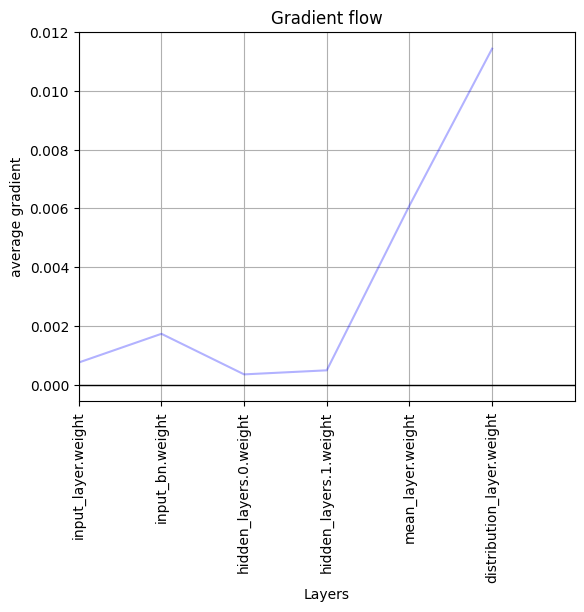

In [116]:
plot_grad_flow(c.named_parameters())

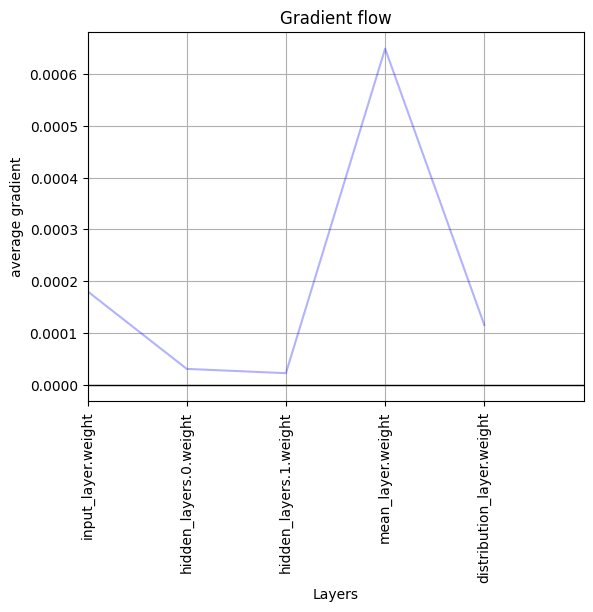

In [23]:
def plot_grad_flow(named_parameters):
    ave_grads = []
    layers = []
    for n, p in named_parameters:
        if p.requires_grad and "bias" not in n and "bn" not in n:  # ← skip bn layers
            layers.append(n)
            ave_grads.append(p.grad.abs().mean().detach().cpu().numpy())
    plt.plot(ave_grads, alpha=0.3, color="b")
    plt.hlines(0, 0, len(ave_grads)+1, linewidth=1, color="k")
    plt.xticks(range(0, len(ave_grads), 1), layers, rotation="vertical")
    plt.xlim(xmin=0, xmax=len(ave_grads))
    plt.xlabel("Layers")
    plt.ylabel("average gradient")
    plt.title("Gradient flow")
    plt.grid(True)
plot_grad_flow(c.named_parameters())

In [16]:
print(a)

FCQV(
  (input_layer): Linear(in_features=20, out_features=128, bias=True)
  (input_bn): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (hidden_layers): ModuleList(
    (0-1): 2 x Linear(in_features=132, out_features=128, bias=True)
  )
  (hidden_bn): ModuleList(
    (0-1): 2 x BatchNorm1d(132, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (output_batch_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)


In [17]:
print(b)

FCQV(
  (input_layer): Linear(in_features=20, out_features=128, bias=True)
  (input_bn): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (hidden_layers): ModuleList(
    (0-1): 2 x Linear(in_features=132, out_features=128, bias=True)
  )
  (hidden_bn): ModuleList(
    (0-1): 2 x BatchNorm1d(132, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (output_batch_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)


In [207]:
acc_

[21.437025278879446,
 21.480350254219957,
 21.322382675483823,
 21.49241150083253,
 21.38842058472801,
 21.2759058913216,
 21.422967745456845,
 21.23207057081163,
 21.40658881282434,
 21.402483746409416,
 21.47780599608086,
 21.288555908948183,
 21.414072196668712,
 21.44170862296596,
 21.36946716415696,
 21.358401192934252,
 21.311748754233122,
 21.44514578883536,
 21.277212105691433,
 21.511831995332614,
 21.286870657466352,
 21.299994016066194,
 21.30471672490239,
 21.413186008576304,
 21.39767190022394,
 21.250682690180838,
 21.403829135466367,
 21.519212752595195,
 21.149476952268742,
 21.4772374444874,
 21.296425852924585,
 21.45965313888155,
 21.334488043095917,
 21.45035059377551,
 21.382268273853697,
 21.484152794932015,
 21.21666512452066,
 21.44586174469441,
 21.381436940748245,
 21.4289539570309,
 21.437252297764644,
 21.45585540216416,
 21.443648722721264,
 21.359752946766093,
 21.52105789153211,
 21.31932983198203,
 21.472803795710206,
 21.412639553043846,
 21.30485154688

In [136]:
arr = uniform_filter1d(rewards, size=50)

In [137]:
x = []
y = []
for i,e in enumerate(arr):
    y.append(i)
    x.append(e)

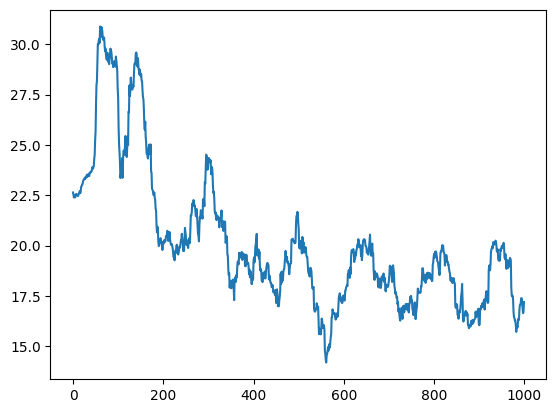

In [138]:
plt.plot(y, x)#20% bias correction, medium-high prioritization rates(40%), proportional prioritization

In [58]:
print(env.action_space.low)   # [0. 0. 0. 0.]
print(env.action_space.high)  # [1. 1. 1. 1.]

[0. 0. 0. 0.]
[1. 1. 1. 1.]


In [23]:
test_state = torch.zeros(1, 16).float().to("cpu")
test_state[0, 2] = 0.8
test_state[0, 14] = 1.0
test_state[0, 15] = 0.2
good_action = torch.tensor([[0.6, 0.6, 0.6, 0.6]]).float().to("cpu")
bad_action  = torch.tensor([[0.3, 0.3, 0.3, 0.3]]).float().to("cpu")

for net, name in [(a, "oqa"), (b, "oqb")]:
    net.eval()
    print(f"{name} Q(good): {net(test_state, good_action).item():.4f}")
    print(f"{name} Q(bad):  {net(test_state, bad_action).item():.4f}")
    net.train()

oqa Q(good): 47.9327
oqa Q(bad):  47.9328
oqb Q(good): 48.3837
oqb Q(bad):  48.4034


In [20]:
real_state = torch.tensor(env.reset()[0]).float().unsqueeze(0).to("cpu")
good_action = torch.tensor([[0.6, 0.6, 0.6, 0.6]]).float().to("cpu")
bad_action  = torch.tensor([[0.3, 0.3, 0.3, 0.3]]).float().to("cpu")

for net, name in [(a, "oqa"), (b, "oqb")]:
    net.eval()
    print(f"{name} Q(good): {net(real_state, good_action).item():.4f}")
    print(f"{name} Q(bad):  {net(real_state, bad_action).item():.4f}")
    net.train()

RuntimeError: running_mean should contain 16 elements not 20

In [69]:
env.close()

In [1]:
from env.drone_env import DRONE_MASS, GRAVITY, MAX_THRUST

hover_throttle = (DRONE_MASS * GRAVITY) / (4 * MAX_THRUST)
print(f"Hover throttle: {hover_throttle:.4f}")

Hover throttle: 0.5000
